<a href="https://colab.research.google.com/github/dystaSatria/Deep-Learning/blob/main/Deep-Learning%20/Internship%20Projects/mcc/mcc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DEMONSTRASI MATTHEWS CORRELATION COEFFICIENT

=== Contoh Asli ===
True labels:  [1, 0, 1, 1, 0, 0, 1, 0, 0, 0]
Predictions:  [1, 0, 1, 1, 0, 1, 0, 0, 0, 0]
Matthews Correlation Coefficient: 0.583
Accuracy: 0.800
Precision: 0.750
Recall: 0.750
F1-Score: 0.750
Confusion Matrix:
TN: 5, FP: 1
FN: 1, TP: 3

=== Prediksi Sempurna ===
True labels:  [1, 0, 1, 1, 0, 0, 1, 0, 0, 1]
Predictions:  [1, 0, 1, 1, 0, 0, 1, 0, 0, 1]
Matthews Correlation Coefficient: 1.000
Accuracy: 1.000
Precision: 1.000
Recall: 1.000
F1-Score: 1.000
Confusion Matrix:
TN: 5, FP: 0
FN: 0, TP: 5

=== Prediksi Terburuk ===
True labels:  [1, 0, 1, 1, 0, 0, 1, 0, 0, 1]
Predictions:  [0, 1, 0, 0, 1, 1, 0, 1, 1, 0]
Matthews Correlation Coefficient: -1.000
Accuracy: 0.000
Precision: 0.000
Recall: 0.000
F1-Score: 0.000
Confusion Matrix:
TN: 0, FP: 5
FN: 5, TP: 0

=== Prediksi Acak ===
True labels:  [1, 0, 1, 1, 0, 0, 1, 0, 0, 1]
Predictions:  [0, 1, 0, 0, 0, 1, 0, 0, 0, 1]
Matthews Correlation Coefficient: -0.218
Accuracy: 0.40

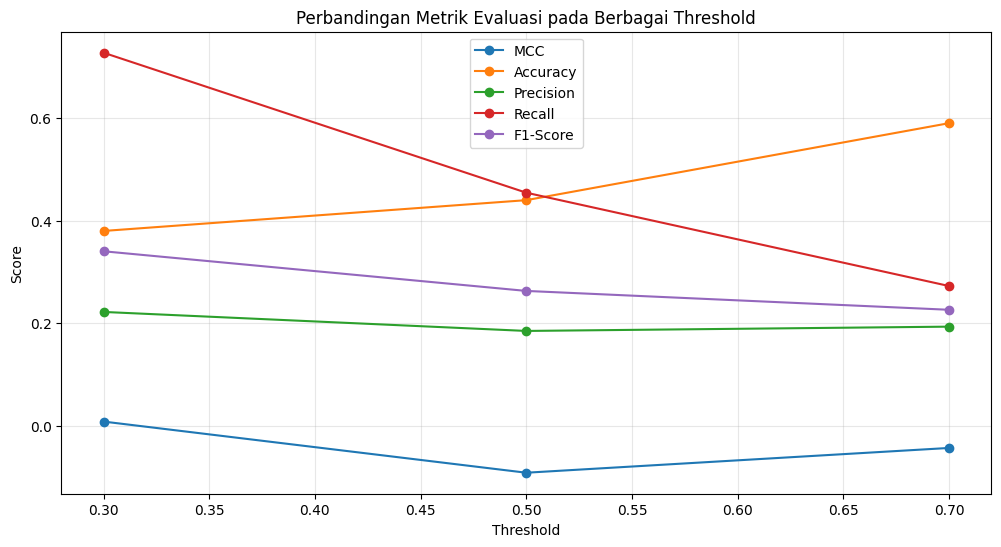


KESIMPULAN TENTANG MCC:

1. MCC berkisar dari -1 hingga +1:
   - +1: Prediksi sempurna
   - 0: Prediksi acak/tidak ada korelasi
   - -1: Prediksi berlawanan sempurna

2. Keunggulan MCC:
   - Memperhitungkan semua nilai dalam confusion matrix (TP, TN, FP, FN)
   - Lebih robust terhadap dataset tidak seimbang dibanding accuracy
   - Memberikan gambaran yang lebih realistis tentang performa model

3. Kapan menggunakan MCC:
   - Dataset dengan kelas tidak seimbang
   - Ketika False Positive dan False Negative sama-sama penting
   - Sebagai metrik tambahan bersama precision, recall, dan F1-score

4. Interpretasi:
   - MCC > 0.8: Prediksi sangat baik
   - MCC 0.6-0.8: Prediksi baik
   - MCC 0.4-0.6: Prediksi sedang
   - MCC 0.2-0.4: Prediksi lemah
   - MCC < 0.2: Prediksi sangat lemah



In [13]:
from sklearn.metrics import matthews_corrcoef, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_classifier(y_true, y_pred, scenario_name):
    """
    Fungsi untuk mengevaluasi performa classifier dengan berbagai metrik
    """
    print(f"\n=== {scenario_name} ===")
    print(f"True labels:  {y_true}")
    print(f"Predictions:  {y_pred}")

    # Hitung berbagai metrik
    mcc = matthews_corrcoef(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"Matthews Correlation Coefficient: {mcc:.3f}")
    print(f"Accuracy: {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-Score: {f1:.3f}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print(f"Confusion Matrix:")
    print(f"TN: {cm[0,0]}, FP: {cm[0,1]}")
    print(f"FN: {cm[1,0]}, TP: {cm[1,1]}")

    return mcc, accuracy, precision, recall, f1

def plot_confusion_matrix(y_true, y_pred, title):
    """
    Fungsi untuk memplot confusion matrix
    """
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title(title)
    plt.show()

# Contoh 1: Kode asli yang diberikan
print("DEMONSTRASI MATTHEWS CORRELATION COEFFICIENT")
print("=" * 50)

y_true_original = [1, 0, 1, 1, 0, 0, 1, 0, 0, 0]
y_pred_original = [1, 0, 1, 1, 0, 1, 0, 0, 0, 0]

evaluate_classifier(y_true_original, y_pred_original, "Contoh Asli")

# Contoh 2: Prediksi sempurna
y_true_perfect = [1, 0, 1, 1, 0, 0, 1, 0, 0, 1]
y_pred_perfect = [1, 0, 1, 1, 0, 0, 1, 0, 0, 1]

evaluate_classifier(y_true_perfect, y_pred_perfect, "Prediksi Sempurna")

# Contoh 3: Prediksi terburuk (berlawanan)
y_true_worst = [1, 0, 1, 1, 0, 0, 1, 0, 0, 1]
y_pred_worst = [0, 1, 0, 0, 1, 1, 0, 1, 1, 0]

evaluate_classifier(y_true_worst, y_pred_worst, "Prediksi Terburuk")

# Contoh 4: Prediksi acak
np.random.seed(42)
y_true_random = [1, 0, 1, 1, 0, 0, 1, 0, 0, 1]
y_pred_random = np.random.choice([0, 1], size=10).tolist()

evaluate_classifier(y_true_random, y_pred_random, "Prediksi Acak")

# Contoh 5: Dataset tidak seimbang (imbalanced)
print("\n" + "="*50)
print("CONTOH DENGAN DATASET TIDAK SEIMBANG")
print("="*50)

# 90% kelas 0, 10% kelas 1
y_true_imbalanced = [0] * 18 + [1] * 2
# Model yang selalu prediksi kelas mayoritas (0)
y_pred_always_0 = [0] * 20
# Model yang lebih baik
y_pred_better = [0] * 18 + [1, 0]  # Prediksi 1 kelas minoritas dengan benar

evaluate_classifier(y_true_imbalanced, y_pred_always_0,
                   "Model Selalu Prediksi Kelas Mayoritas (Dataset Imbalanced)")

evaluate_classifier(y_true_imbalanced, y_pred_better,
                   "Model Lebih Baik (Dataset Imbalanced)")

# Contoh 6: Simulasi performa model pada berbagai threshold
print("\n" + "="*50)
print("SIMULASI PERUBAHAN THRESHOLD")
print("="*50)

# Simulasi probabilitas prediksi
np.random.seed(123)
n_samples = 100
y_true_sim = np.random.choice([0, 1], size=n_samples, p=[0.7, 0.3])  # 30% positif
probabilities = np.random.random(n_samples)

# Berbagai threshold
thresholds = [0.3, 0.5, 0.7]
results = []

for threshold in thresholds:
    y_pred_thresh = (probabilities > threshold).astype(int)
    mcc, acc, prec, rec, f1 = evaluate_classifier(y_true_sim, y_pred_thresh,
                                                 f"Threshold = {threshold}")
    results.append([threshold, mcc, acc, prec, rec, f1])

# Plot hasil
metrics_names = ['Threshold', 'MCC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
results_array = np.array(results)

plt.figure(figsize=(12, 6))
for i, metric in enumerate(metrics_names[1:], 1):
    plt.plot(results_array[:, 0], results_array[:, i], marker='o', label=metric)

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Perbandingan Metrik Evaluasi pada Berbagai Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n" + "="*50)
print("KESIMPULAN TENTANG MCC:")
print("="*50)
print("""
1. MCC berkisar dari -1 hingga +1:
   - +1: Prediksi sempurna
   - 0: Prediksi acak/tidak ada korelasi
   - -1: Prediksi berlawanan sempurna

2. Keunggulan MCC:
   - Memperhitungkan semua nilai dalam confusion matrix (TP, TN, FP, FN)
   - Lebih robust terhadap dataset tidak seimbang dibanding accuracy
   - Memberikan gambaran yang lebih realistis tentang performa model

3. Kapan menggunakan MCC:
   - Dataset dengan kelas tidak seimbang
   - Ketika False Positive dan False Negative sama-sama penting
   - Sebagai metrik tambahan bersama precision, recall, dan F1-score

4. Interpretasi:
   - MCC > 0.8: Prediksi sangat baik
   - MCC 0.6-0.8: Prediksi baik
   - MCC 0.4-0.6: Prediksi sedang
   - MCC 0.2-0.4: Prediksi lemah
   - MCC < 0.2: Prediksi sangat lemah
""")